# **Face Mask Detection using CNN**

**Project Description**

The goal of this project is to develop a deep learning model using Convolutional Neural Networks (CNN) that can automatically detect whether a person in an image or video is wearing a face mask or not.

**Objectives**
- Understand image classification using deep learning
- Perform data preprocessing and augmentation
- Train and evaluate a CNN-based model

The model should take an input image (or video frame) and classify it into:
- With Mask
- Without Mask

In [1]:
import kagglehub

#  Download latest version
path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

print("Path to dataset files:", path)

100%|██████████| 163M/163M [00:11<00:00, 15.2MB/s] 

Extracting files...


Path to dataset files: C:\Users\Administrator\.cache\kagglehub\datasets\omkargurav\face-mask-dataset\versions\1


**Data Understanding**

In [2]:
import os
print(os.listdir(path))


['data']


In [3]:
print("Data", os.listdir(os.path.join(path, 'data')))


Data ['without_mask', 'with_mask']


In [4]:
print("Withoout Mask", os.path.join(path, 'without_mask'))
print("With Mask", os.path.join(path, 'with_mask'))

Withoout Mask C:\Users\Administrator\.cache\kagglehub\datasets\omkargurav\face-mask-dataset\versions\1\without_mask
With Mask C:\Users\Administrator\.cache\kagglehub\datasets\omkargurav\face-mask-dataset\versions\1\with_mask


In [5]:

dataset_path = kagglehub.dataset_download("omkargurav/face-mask-dataset")

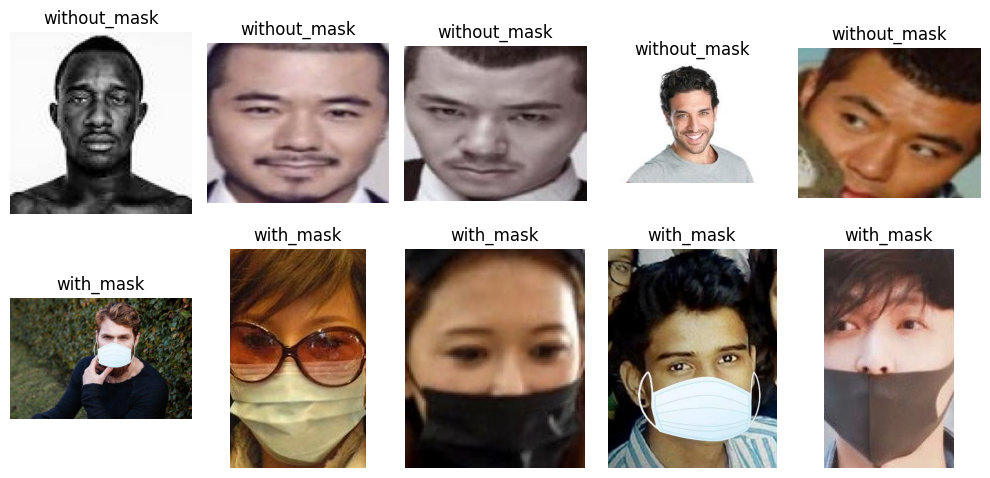

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
# Python image library
base_path = os.path.join(path,'data')
plt.figure(figsize=(10,12))

i = 1
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)
  #print(class_path)

  if os.path.isdir(class_path):
    images = os.listdir(class_path)[:5]
    for img in images:
      image_path = os.path.join(class_path,img)
      img = Image.open(image_path)

      plt.subplot(5,5,i)
      plt.imshow(img)
      plt.title(class_name)
      plt.axis('off')
      i+=1
plt.tight_layout()
plt.show()

In [7]:
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)
  #print(class_path)

  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    print(class_name,':',count)

without_mask : 3828
with_mask : 3725


**Create dataframe which includes imagepath and  labels**

In [8]:
import pandas as pd
data=[]
base_path = os.path.join(path,'data')
for class_name in os.listdir(base_path):
  class_path = os.path.join(base_path,class_name)

  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      data.append([img_path,class_name])
df = pd.DataFrame(data,columns=['image_path','label'])

**Shuffle data**

In [9]:
df = df.sample(frac=1,random_state=42).reset_index(drop=True)

**Split data for training,validation and testing**

In [10]:
train_size = int(0.7* len(df))
test_size = int(0.15* len(df))
val_size = int(0.15* len(df))
print("train_size---->",train_size)
print("test_size---->",test_size)
print("val_size---->",val_size)

train_size----> 5287
test_size----> 1132
val_size----> 1132


In [11]:
tran_data = df.iloc[:train_size]

tst_data = df.iloc[train_size:train_size+test_size]
vali_data = df.iloc[train_size+test_size :]
print("train_data--->",len(tran_data))
print("test_data--->",len(tst_data))
print("val_data--->",len(vali_data))

train_data---> 5287
test_data---> 1132
val_data---> 1134


**find size of image**

In [15]:
img = df['image_path'][0]
image = Image.open(img)
width,height = image.size
print(height,width)

189 267


**Data preprocessing**

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
#ImageDataGenerator used for data cleaning
batch_size = 32
img_height = 224
img_width = 224

In [18]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

In [19]:
train_data = train_datagen.flow_from_dataframe(
    dataframe=tran_data,
    x_col='image_path',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_data = train_datagen.flow_from_dataframe(
    dataframe=vali_data,
    x_col='image_path',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

tst_data = train_datagen.flow_from_dataframe(
    dataframe=tst_data,
    x_col='image_path',
    y_col='label',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5287 validated image filenames belonging to 2 classes.
Found 1134 validated image filenames belonging to 2 classes.
Found 1132 validated image filenames belonging to 2 classes.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

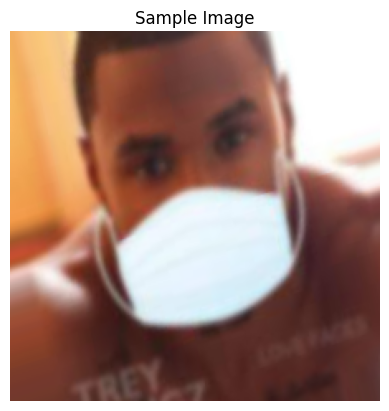

In [20]:
#Visualization of images

images, labels = next(train_data)
plt.imshow(images[0])
plt.title("Sample Image")

plt.axis('off')

In [21]:
for image_batch, labels_batch in train_data:
    print(f"Train Shape: {image_batch.shape} (Batches = {len(train_data)})")
    print(f"Train Label Shape: {labels_batch.shape}\n")
    break

for image_batch, labels_batch in val_data:
    print(f"Validation Shape: {image_batch.shape} (Batches = {len(val_data)})")
    print(f"Validation Label Shape: {labels_batch.shape}\n")
    break

Train Shape: (32, 224, 224, 3) (Batches = 166)
Train Label Shape: (32,)

Validation Shape: (32, 224, 224, 3) (Batches = 36)
Validation Label Shape: (32,)



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


**Model building with CNN**

In [22]:
from tensorflow.keras import models,layers
from tensorflow.keras.optimizers import Adam


In [23]:


n_classes=2
cnn_model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
    ])

In [24]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from tensorflow.keras.losses import BinaryCrossentropy

cnn_model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [27]:
cnn = cnn_model.fit(
      train_data,
      epochs=10,
      validation_data=val_data,
      verbose=1,
      callbacks=[early_stop]
)

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 428s 3s/step - accuracy: 0.8339 - loss: 0.3693 - val_accuracy: 0.8933 - val_loss: 0.2674
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.8869 - loss: 0.2785 - val_accuracy: 0.8880 - val_loss: 0.2496
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.8931 - loss: 0.2598 - val_accuracy: 0.8951 - val_loss: 0.2434
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 449s 2s/step - accuracy: 0.9037 - loss: 0.2268 - val_accuracy: 0.8880 - val_loss: 0.2627
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.9107 - loss: 0.2194 - val_accuracy: 0.9162 - val_loss: 0.2057
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.9138 - loss: 0.2160 - val_accuracy: 0.9136 - val_loss: 0.2223
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 432s 3s/step - accuracy: 0.9200 - loss: 0.1976 - val_accuracy: 0.9277 - val_loss: 0.1801
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 449s 3s/step - accuracy: 0.9255 - loss: 0.1925 - val_accu

In [28]:
# Evaluate on the training data
train_loss, train_accuracy = cnn_model.evaluate(train_data, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(tst_data, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

166/166 ━━━━━━━━━━━━━━━━━━━━ 150s 901ms/step - accuracy: 0.9531 - loss: 0.1210
Training accuracy: 0.9531
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 949ms/step - accuracy: 0.9390 - loss: 0.1510
Test accuracy: 0.9390


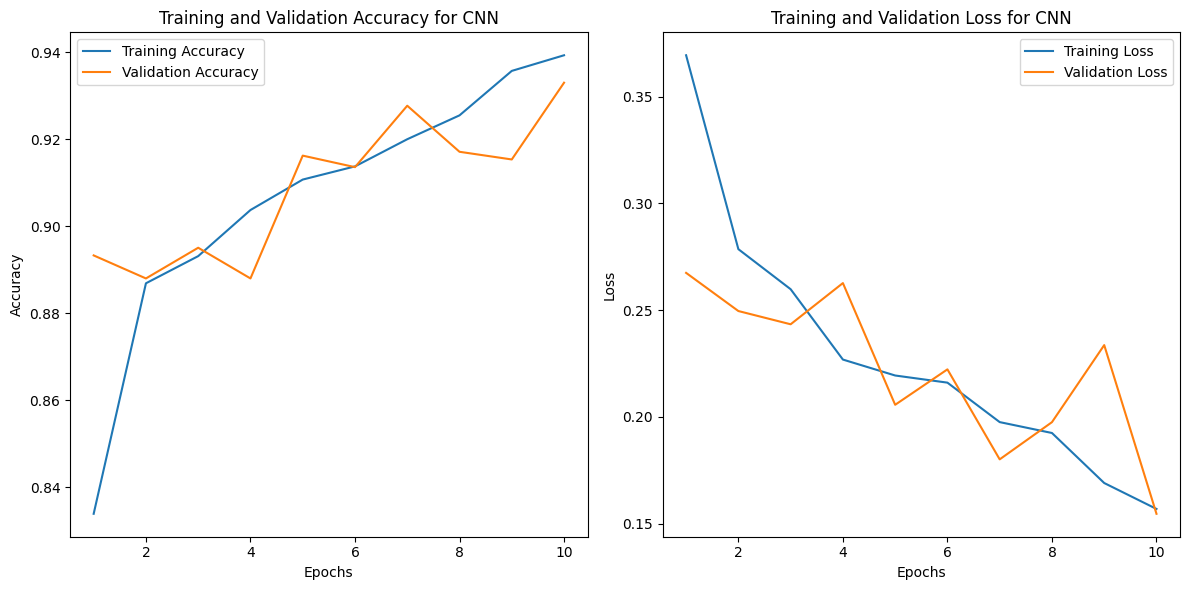

In [29]:
# Retrieve metrics from the training history
acc = cnn.history['accuracy']
val_acc = cnn.history['val_accuracy']
loss = cnn.history['loss']
val_loss = cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
val_data.reset()

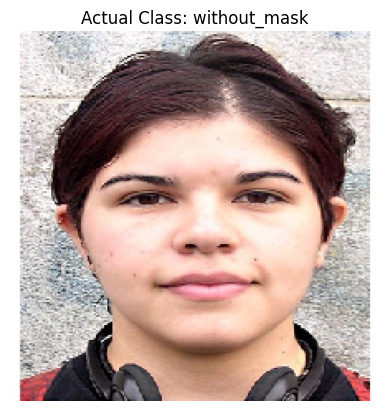

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Predicted Class: without_mask


In [31]:
import os
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
base_path = os.path.join(dataset_path, 'data')

# Pick random class (with_mask / without_mask)
class_name = random.choice(os.listdir(base_path))

# Pick random image from that class
class_path = os.path.join(base_path, class_name)
img_name = random.choice(os.listdir(class_path))

img_path = os.path.join(class_path, img_name)

# Display image
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.title(f"Actual Class: {class_name}")
plt.axis('off')
plt.show()

# Preprocess image
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = cnn_model.predict(img_array)

# Binary classification logic
if prediction[0][0] > 0.5:
    predicted_class = "without_mask"
else:
    predicted_class = "with_mask"

# Print prediction
print("Predicted Class:", predicted_class)

In [32]:
y_pred_prob = cnn_model.predict(val_data)

print("First 10 predictions:")
print(y_pred_prob[:10])

36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 842ms/step
First 10 predictions:
[[1.00860394e-04]
 [9.99998927e-01]
 [9.98733103e-01]
 [9.99947906e-01]
 [8.40938883e-05]
 [9.98708546e-01]
 [9.99172032e-01]
 [9.20159101e-01]
 [9.86229002e-01]
 [5.14083695e-05]]


In [33]:
print(train_data.class_indices)

{'with_mask': 0, 'without_mask': 1}


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
predictions = cnn_model.predict(val_data)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Accuracy
loss, accuracy = cnn_model.evaluate(val_data)
print("Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(val_data.classes, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(val_data.classes, y_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 834ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 836ms/step - accuracy: 0.9347 - loss: 0.1612
Accuracy: 0.9347442388534546

Confusion Matrix:
[[532  34]
 [ 45 523]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       566
           1       0.94      0.92      0.93       568

    accuracy                           0.93      1134
   macro avg       0.93      0.93      0.93      1134
weighted avg       0.93      0.93      0.93      1134



In [37]:
cnn_model.save('face_mask_model.h5')

In [38]:
from google.colab import files
files.download('face_mask_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
!pip install tensorflowjs
!tensorflowjs_converter --input_format keras face_mask_model.h5 tfjs_model/

INFO: pip is looking at multiple versions of tf-keras to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 783.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.47.0
    Uninstalling wheel-0.47.0:
      Successfully uninstalled wheel-0.47.0
  Attempting u

2026-05-17 18:29:52.525910: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779042592.542789   31980 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779042592.547028   31980 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779042592.559104   31980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779042592.559149   31980 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779042592.559153   31980 computation_placer.cc:177] computation placer alr

In [42]:
!zip -r tfjs_model.zip tfjs_model/

from google.colab import files
files.download('tfjs_model.zip')

  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/group1-shard8of11.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 84%)
  adding: tfjs_model/group1-shard6of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard5of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard11of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard10of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard3of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard4of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard9of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard7of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard1of11.bin (deflated 7%)
  adding: tfjs_model/group1-shard2of11.bin (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>